# Exploration


proposed methods:

1. K-nearest neighbor
2. Logistic regression
3. Discriminant analysis
    a. Linear Discriminant Analysis
    b. Quadratic Discriminant analysis
4. Tree-based methods:
    a. classification trees
    b. random forsest
    c. bagging
5. Boosting
6. Support Vector Machines

## Order of operations

### Explore data

1. Explore the data, plotting
2. Normalize the data, perform outlier detection and encode categorical values (one-hot or similar)
3. Perform Feature selection

### For selected methods

1. Implement the method, either via something like sklearn or write custom implementation
2. Tune the method to perform well
3. Evaluate performance using cross validation. We are aonly allowed to validate on training_data.csv, but we can test on songs_to_classify.

### Handin

1. Select best method and submit prediction as a string of zeros and ones
2. Handin zip file with what is needed to recreate and report

In [171]:
# Import modules
import numpy as np
import pandas as pd
import random

# We use searborn for prettier plots
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

# To get typehints
from matplotlib.figure import Figure
from matplotlib.axes import Axes
from numpy.typing import NDArray
from typing import * # bad practice but I dont care

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
# Apply the default theme
sns.set_theme()

In [172]:
# Load data
train = pd.read_csv("labs/lab_1_music_taste_prediction/data/training_data.csv")
test = pd.read_csv("labs/lab_1_music_taste_prediction/data/songs_to_classify.csv")
print(train.shape, test.shape)

(750, 14) (200, 13)


In [173]:
# Inspect data

sample = train.sample(5)
sample

,acousticness,danceability,duration,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,label
506,0.4350,0.658,242861,0.591,0.000082,2,0.123,-5.221,1,0.0647,126.829,4,0.483,0
357,0.0682,0.602,245053,0.796,0.120000,0,0.150,-3.657,0,0.1030,126.060,4,0.265,1
133,0.0141,0.697,228427,0.949,0.000000,0,0.748,-7.202,1,0.0353,132.379,4,0.904,0
250,0.7970,0.292,175667,0.771,0.196000,10,0.148,-3.726,0,0.0453,128.235,4,0.228,1
299,0.7460,0.486,247227,0.513,0.002130,0,0.113,-9.397,1,0.0349,129.131,4,0.394,1


## Exploring the data

In [174]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   acousticness      750 non-null    float64
 1   danceability      750 non-null    float64
 2   duration          750 non-null    int64  
 3   energy            750 non-null    float64
 4   instrumentalness  750 non-null    float64
 5   key               750 non-null    int64  
 6   liveness          750 non-null    float64
 7   loudness          750 non-null    float64
 8   mode              750 non-null    int64  
 9   speechiness       750 non-null    float64
 10  tempo             750 non-null    float64
 11  time_signature    750 non-null    int64  
 12  valence           750 non-null    float64
 13  label             750 non-null    int64  
dtypes: float64(9), int64(5)
memory usage: 82.2 KB


In [175]:
test.info()


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   acousticness      200 non-null    float64
 1   danceability      200 non-null    float64
 2   duration          200 non-null    int64  
 3   energy            200 non-null    float64
 4   instrumentalness  200 non-null    float64
 5   key               200 non-null    int64  
 6   liveness          200 non-null    float64
 7   loudness          200 non-null    float64
 8   mode              200 non-null    int64  
 9   speechiness       200 non-null    float64
 10  tempo             200 non-null    float64
 11  time_signature    200 non-null    int64  
 12  valence           200 non-null    float64
dtypes: float64(9), int64(4)
memory usage: 20.4 KB


we see no null values

### Single feature plots

Getting to know the features, not their relations

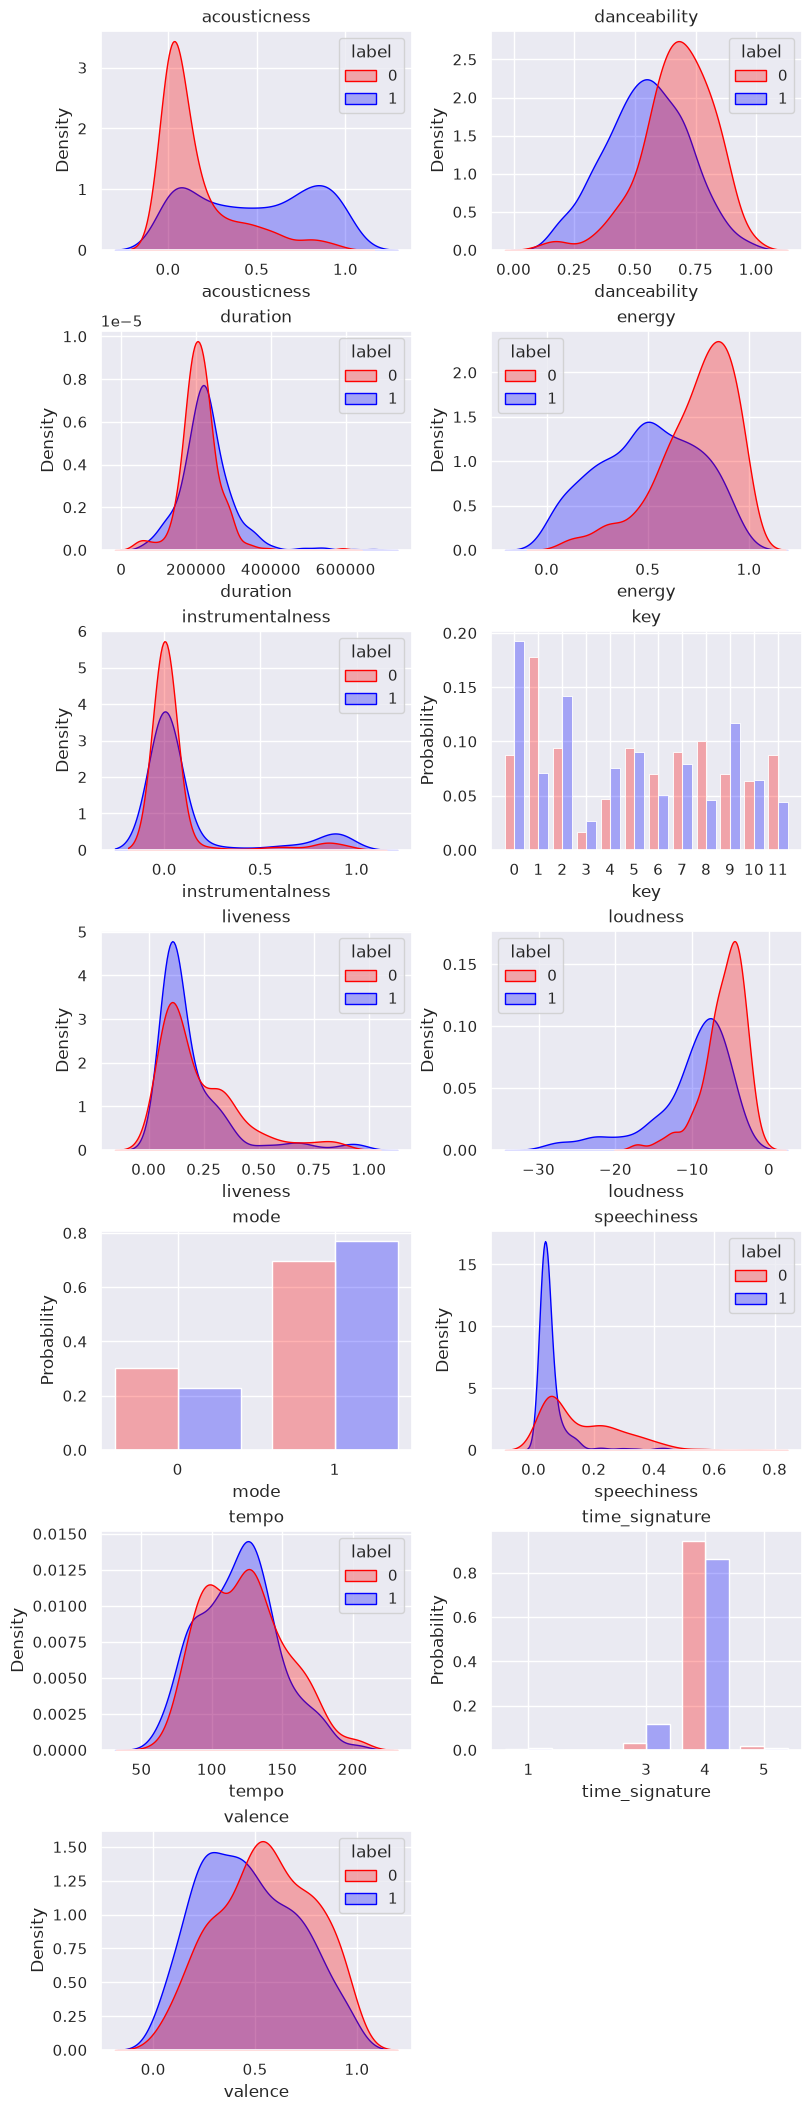

In [176]:
"""
label 0 -> red
label 1 -> blue

we have a bunch of different features

one start is to just plot the rows w.r.t. a single feature
"""

PALETTE = {0: "red", 1: "blue"}
CMAP = LinearSegmentedColormap.from_list("label", ["red", "white", "blue"])
DISCRETE_COLS = ["key", "mode", "time_signature"]

def single_feature_plots(df: pd.DataFrame, label_col_name: str = "label", n_fig_cols = 2) -> None:

    """
    each plot: feature col and color from its label
    """

    feat_cols = [col for col in df.columns if col != label_col_name]
    n_feat_cols = len(feat_cols)

    n_fig_rows = int(np.ceil(n_feat_cols / n_fig_cols))
    fig, axs = plt.subplots(n_fig_rows, n_fig_cols, figsize=(4 * n_fig_cols, 3 * n_fig_rows), constrained_layout=True)
    fig: Figure
    axs: List[Axes]
    axs = np.atleast_1d(axs).ravel()


    for ax, col_name in zip(axs, feat_cols):

        # KDE works best with continous data, we use hist for discrete
        if col_name in DISCRETE_COLS:
            cats = np.sort(df[col_name].unique())
            sns.histplot(data=df, x=col_name, hue=label_col_name, palette=PALETTE,
                    discrete=True, stat="probability", common_norm=False,
                    multiple="dodge", shrink=0.8, legend=False, alpha=0.3, ax=ax)
            ax.set_xticks(cats)
        else:
            sns.kdeplot(data=df, x=col_name, hue=label_col_name, palette=PALETTE, alpha=0.3, common_norm=False, fill=True, ax=ax)

        ax.set_title(col_name)


    for ax in axs[n_feat_cols:]:
        ax.set_visible(False)

single_feature_plots(df=train)

### Looking at combinations of features

In [177]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import accuracy_score

"""
in k-fold cross validation
fold = one of the data partitions
split ex train: Fold 2 + Fold 3 + Fold 4 + Fold 5, validate: Fold 1

fitting with classifier, then calling .feature_importances_ -> "which features did
this models use to split?"
feature_importances measured in "gini importance" / "mean decrease in impurity" (float)

split is both a decision made at a node of the decision tree, and it partitions the training data
which reached that node.

cross-val says how good the model is
just fitting with decision tree does not say how good the tree is unless we validate it,
which is why we are usign cross-val. We could of course partition the train set into train and val,
but we use cross-val to do a better job of it.
"""


from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from itertools import combinations

# Train a Decision Tree Classifier for each feature X
def cross_val_decision_tree(
    train_features: pd.DataFrame,
    train_labels: pd.DataFrame,
    max_depth: int = 5,
    folds: int = 5,
) -> NDArray:
    # We don't need to scale the features for a tree-based classifier
    clf = DecisionTreeClassifier(max_depth=max_depth, random_state=SEED)
    # use roc_auc b.c. we are not sure about the nature of how we value the confusion matrix
    k_scores = cross_val_score(
        estimator=clf, X=train_features, y=train_labels, cv=folds, scoring="roc_auc"
    )
    return k_scores.mean()


train_features = train.drop("label", axis=1)
train_labels = train["label"]

# importances = get_feature_importances(train_features, train_labels)
single_feature_scores: Dict[str, np.float64] = {
    feature: cross_val_decision_tree(
        train_features[[feature]], train_labels, max_depth=4, folds=5
    )
    for feature in train_features
}
pair_feature_scores: List[Tuple[str, str, np.float64, np.float64]] = [
    (
        feat1,
        feat2,
        cross_val_decision_tree(train_features[[feat1, feat2]], train_labels),
        max(single_feature_scores[feat1], single_feature_scores[feat2]),
    )
    for feat1, feat2 in combinations(train_features, 2)
]

In [178]:
"""
We see if any of the combinations have meaningful effects, and define
"gain" as the difference between the pair score and the best single score

We see that some feature combinations decrease the performance, whereas
some result in a big increase, such as looking at the pair of energy and speeciness
which has almost 10% gain in ROC_AUC, i.e. their combination seems to be more telling
than any of the individual components.
"""

singles = (
    pd.Series(single_feature_scores, name="ROC_AUC")
    .rename_axis("feature")
    .reset_index()
    .sort_values("ROC_AUC", ascending=False)
)
pairs = pd.DataFrame(
    pair_feature_scores, columns=["feat1", "feat2", "pair", "best_single"]
)
pairs["gain"] = pairs["pair"] - pairs["best_single"]
pairs = pairs.sort_values(by="gain", ascending=False)
pairs["name"] = pairs["feat1"] + " + " + pairs["feat2"]

Text(0.5, 1.0, 'Single feature ROC_AUC score')

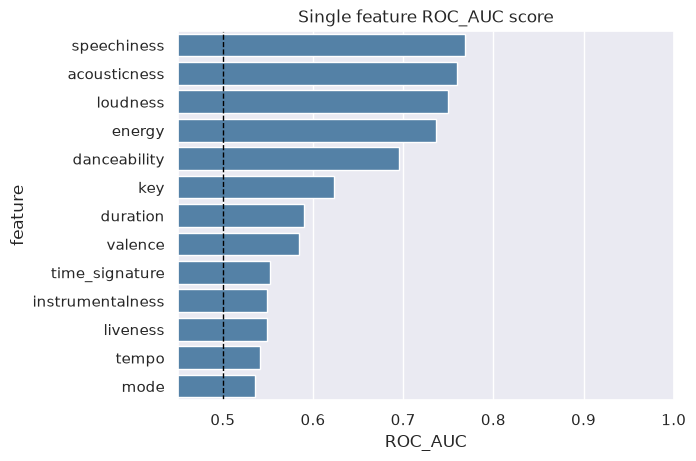

In [179]:
ax = sns.barplot(data=singles, x="ROC_AUC", y="feature", color="steelblue")
ax.axvline(x=0.5, color="black", ls="--", lw=1)
ax.set_xlim(0.45, 1)
ax.set_title("Single feature ROC_AUC score")

Text(0.5, 1.0, 'Feature pair ROC_AUC gain')

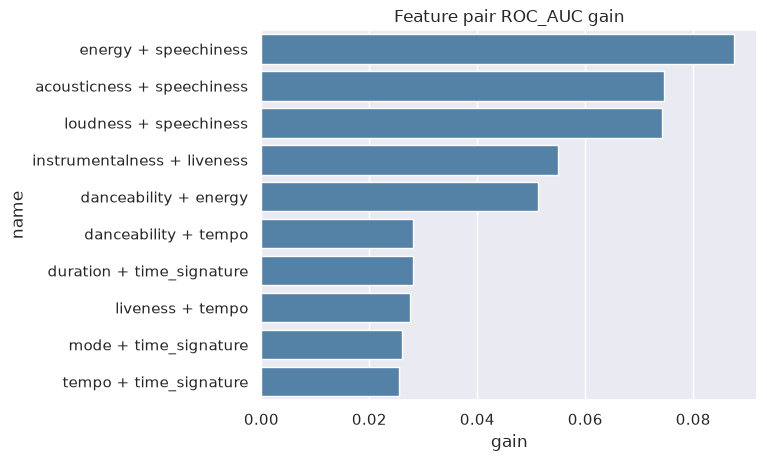

In [180]:
ax = sns.barplot(data=pairs.nlargest(10, "gain"), x="gain", y="name", color="steelblue")
ax.set_title("Feature pair ROC_AUC gain")

Text(0.5, 1.0, 'Feature pairs ROC_AUC score')

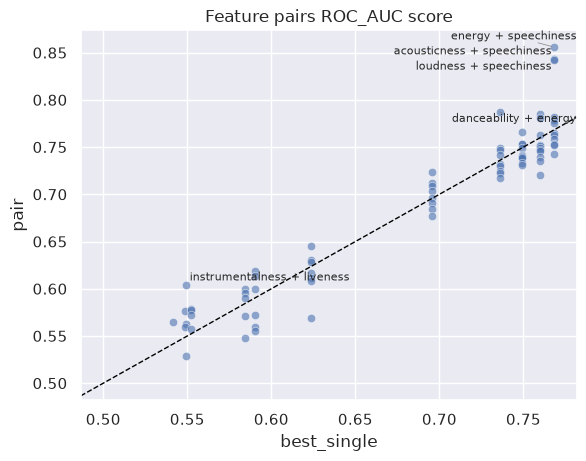

In [181]:
from adjustText import adjust_text

ax = sns.scatterplot(data=pairs, x="best_single", y="pair", alpha=0.6)
ax.axline(
    (0.5, 0.5), slope=1, color="black", ls="--", lw=1
)  # show y = x, which is if they are the same

texts = [ax.text(r["best_single"], r["pair"], r["name"], fontsize=8) for _, r in pairs.nlargest(5, "gain").iterrows()]
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))
ax.set_title("Feature pairs ROC_AUC score")

In [194]:
def plot_cont_cont(
    df: pd.DataFrame, ax: Axes, cont1: str, cont2: str, kde_thresh=0.3, label_col_name: str = "label"
):
    """Just a normal scatterplot with hue as the label"""
    sns.scatterplot(
        df, x=cont1, y=cont2, palette=PALETTE, alpha=0.3, hue=label_col_name, ax=ax
    )

    kde_clip = None
    kde_cut = 0

    sns.kdeplot(
        df,
        x=cont1,
        y=cont2,
        common_norm=False,
        levels=5,
        thresh=kde_thresh,
        clip=kde_clip,
        cut=kde_cut,
        fill=False,
        palette=PALETTE,
        alpha=0.3,
        hue=label_col_name,
        ax=ax,
    )


def plot_disc_cont(
    df: pd.DataFrame, ax: Axes, disc: str, cont: str, label_col_name: str = "label"
):
    """We can do a violin/box plot per label"""
    sns.violinplot(
        df,
        x=disc,
        y=cont,
        split=True,
        palette=PALETTE,
        alpha=0.3,
        cut=0,
        inner="quart",
        hue=label_col_name,
        ax=ax,
    )


def plot_disc_disc(
    df: pd.DataFrame, ax: Axes, disc1: str, disc2: str, min_n = 20, label_col_name: str = "label"
):
    """
    We can do some heatmap variant of labels with counts annotated

    Specifically, P(label=1 | disc1, disc2)
    """
    rate = pd.crosstab(df[disc1], df[disc2], values=df[label_col_name], aggfunc="mean")
    n    = pd.crosstab(df[disc1], df[disc2])
    labels = rate.round(2).astype(str) + "\n(n=" + n.astype(str) + ")"
    sns.heatmap(rate, ax=ax, cmap=CMAP, vmin=0, vmax=1, center=0.5,
                annot=labels, fmt="", mask=(n < min_n), cbar=False)

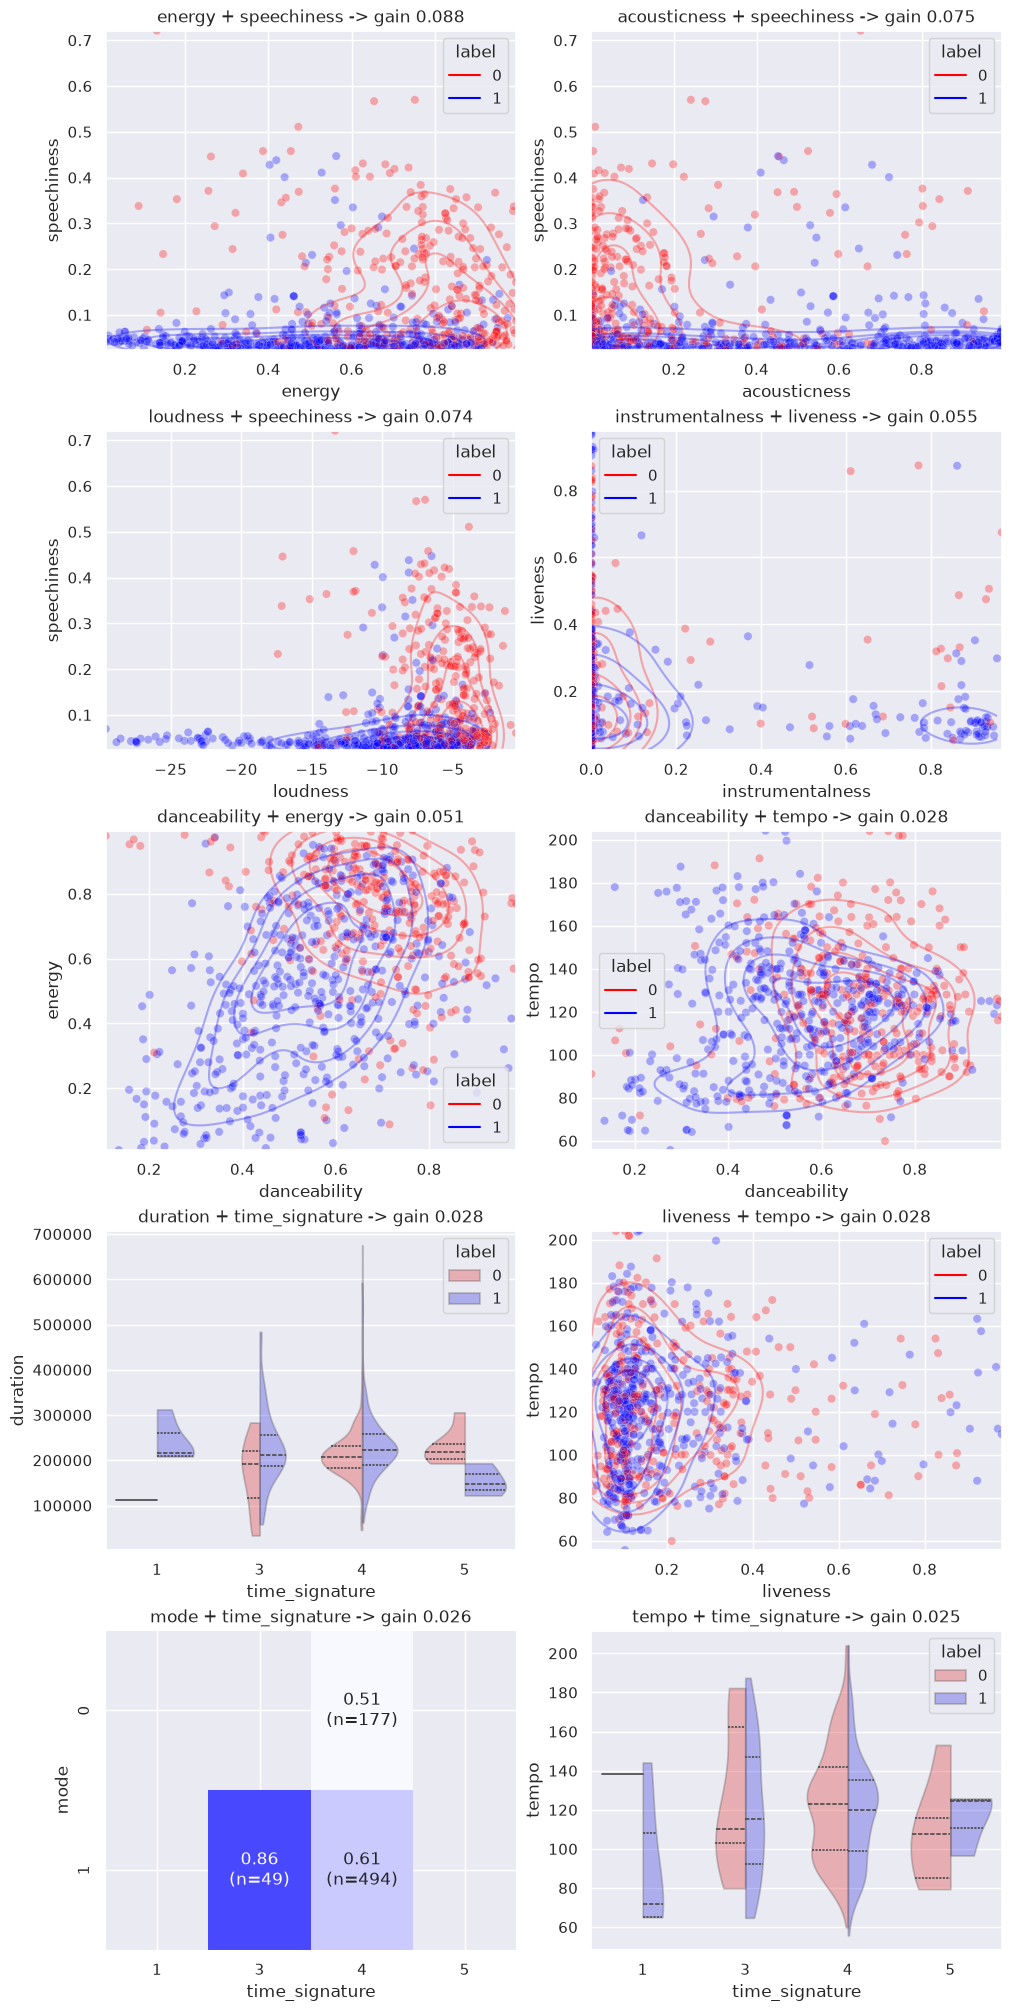

In [195]:
n = 10
cols = 2
rows = int(np.ceil(n / cols))


fig, axs = plt.subplots(rows, cols, figsize=(5*cols, 4*rows), constrained_layout=True)
axs: List[Axes]
axs = np.atleast_1d(axs).flatten()

feature_selection = pairs.nlargest(n, "gain")
for i, ax in enumerate(axs):
    fs_row = feature_selection.iloc[i]
    feat1, feat2 = fs_row[["feat1", "feat2"]]

    feat1_disc = feat1 in DISCRETE_COLS 
    feat2_disc = feat2 in DISCRETE_COLS

    if feat1_disc and feat2_disc:
        plot_disc_disc(train,ax,feat1,feat2)
    elif not feat1_disc and not feat2_disc:
        plot_cont_cont(train, ax, feat1, feat2, kde_thresh=0.3)
    else:
        if feat1_disc:
            plot_disc_cont(train, ax, disc=feat1, cont=feat2)
        else:
            plot_disc_cont(train, ax, disc=feat2, cont=feat1)

    ax.set_title(f"{fs_row['name']} -> gain {round(fs_row['gain'], 3)}")

### Interpreting the results (todo)

all single features showed a ROC AUC over 0.5
within the pairs, we a range of large gain ~ 0.1, neutral and even negative gain

the feature importance was calculated using k-fold cross validation on decision trees of a certain depth. That depth has a meaningful impact on the decision tree and therefor on the emerging feature importances and combination effects.


We should see this exploration as ...



### Next steps:

- seeing feature importance across different models and stuff, so that we can see which features truly seem robustly important across models (cleanup and standardize the cells above so that we can more or less invoke a parent function that explores the stuff based on selected model and like hyperparameters etc)

- actually setting up the different models for training
    - requires some training validation utils like plotting etc
    - for each mentioned variant in the lab instructions, we want to write about it like how it affects things like regularuzation, scaling, feature engineering importance, etc, if validation methods should differ
        - like for example if we wanted to use some kernel method, then we have a bunch of different suggestions for kernels etc


